## Employee Salary prediction
Here we will be created model for same Position Salary dataset for same business problem. We will see which model will give us the better results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Position_Salaries.csv')
data.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
X = data.iloc[:, 1:-1].values
Y = data.iloc[:, -1].values

print(X)
print(Y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [4]:
print(X.shape)
print(Y.shape)

(10, 1)
(10,)


### Check missing values

In [5]:
print(data.isnull().sum())

Position    0
Level       0
Salary      0
dtype: int64


### Feature Scaling
Feature Scaling is a mandatory step while using SVR bec it's a distance-based algo.
- Here we are training our model on whole dataset and not splitting it. Hence we will do feature scaling in complete dataset instead of training data.
- Also here we have target column with regression values, so we will scale these as well.

In [6]:
# tranform Y from 1D to 2D array - expected format for StandardScalar class
Y = Y.reshape(len(Y), 1)
Y.shape

(10, 1)

In [7]:
print(Y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


In [8]:
from sklearn.preprocessing import StandardScaler
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
print(X_scaled)

[[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]


In [9]:
Y_scaler = StandardScaler()
Y_scaled = Y_scaler.fit_transform(Y)
print(Y_scaled)

[[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


### Training SVR on whole dataset

In [10]:
from sklearn.svm import SVR

regressor = SVR(kernel='rbf')

In [12]:
regressor.fit(X_scaled, Y_scaled)

c:\Users\gusai\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVR()

### Predicting new results
- new unseen data should be in similar X_scaled, bec model is trained in it.
- new predicted values will also be a scaled value.
- We will use Inverse feature scaling to get actual scale value.

In [13]:
user_input = 6.5
input_scaled = X_scaler.transform([[user_input]])  # predict method expects a 2D input
predicted = regressor.predict(input_scaled)
print(predicted)

[-0.27861589]


In [ ]:
# convert this scaled value to original scale
predicted = Y_scaler.inverse_transform(predicted.reshape(-1, 1))
print(predicted)
print(predicted.flatten())

[[4.83872099e+10]]
[4.83872099e+10]


### Visualize SVR Results

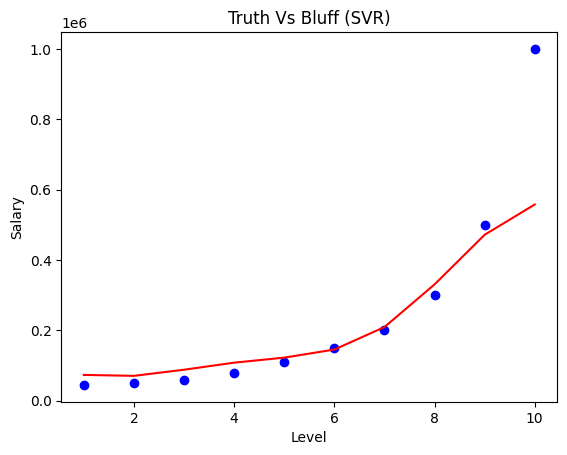

In [24]:
plt.scatter(X, Y, color='blue')
plt.plot(X, Y_scaler.inverse_transform(regressor.predict(X_scaled).reshape(-1,1)), color='red')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.title('Truth Vs Bluff (SVR)')
plt.show()

### Visualization in high resolution and smoother curve

C:\Users\gusai\AppData\Local\Temp\ipykernel_1136\3663938802.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


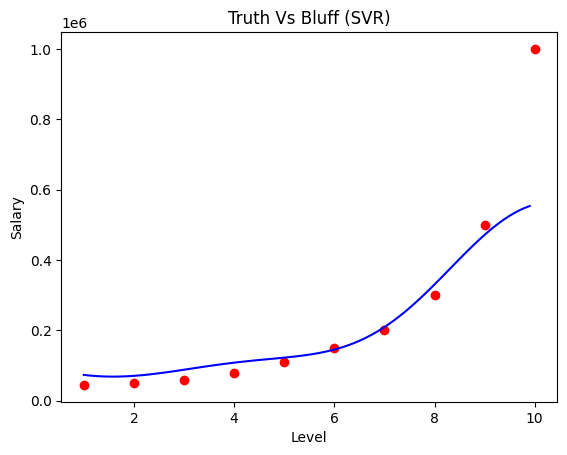

In [26]:
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape(len(X_grid), 1)
plt.scatter(X, Y, color='red')
plt.plot(X_grid, Y_scaler.inverse_transform(regressor.predict(X_scaler.transform(X_grid)).reshape(-1,1)) , color='blue')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.title('Truth Vs Bluff (SVR)')
plt.show()